In [34]:
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path

font = 8
tex_fonts = {
    "font.family": "serif",
    "font.size": font,
    "axes.labelsize": font,
    "axes.titlesize": font,
    "xtick.labelsize": font,
    "ytick.labelsize": font,
    "legend.fontsize": font,
}

plt.rcdefaults()

sns.set_theme(
    context="paper",
    style="whitegrid",
    rc=tex_fonts,
)

ALL_RUNS = [200, 201, 202, 203, 204]
Path('figures/').mkdir(exist_ok=True)

In [24]:
from load_experiments_data import load_experiments_data_spe, load_experiments_data_thm, make_pandas
from typing import Literal

def load_data_spe(case: Literal["expert", "random", "solver_selection", "petsc_default"]):
    sim_data, perf_data, _ = load_experiments_data_spe(
        runs=ALL_RUNS, case=case
    )

    df_sim, df_perf = make_pandas(
        sim_data=sim_data,
        perf_data=perf_data,
        seq_ids=ALL_RUNS,
    )
    return df_sim, df_perf

def load_data_thm(case: Literal["expert", "random", "solver_selection", "petsc_default"]):
    sim_data, perf_data, _ = load_experiments_data_thm(
        runs=ALL_RUNS, case=case
    )

    df_sim, df_perf = make_pandas(
        sim_data=sim_data,
        perf_data=perf_data,
        seq_ids=ALL_RUNS,
    )
    return df_sim, df_perf


spe_data_petsc_default, spe_perf_data_petsc_default = load_data_spe('petsc_default')
spe_data_expert, spe_perf_data_expert = load_data_spe('expert')
spe_data_solver_selection, spe_perf_data_solver_selection = load_data_spe('solver_selection')
spe_data_random, spe_perf_data_random = load_data_spe('random')

thm_data_petsc_default, thm_perf_data_petsc_default = load_data_thm('petsc_default')
thm_data_expert, thm_perf_data_expert = load_data_thm('expert')
thm_data_solver_selection, thm_perf_data_solver_selection = load_data_thm('solver_selection')
thm_data_random, thm_perf_data_random = load_data_thm('random')

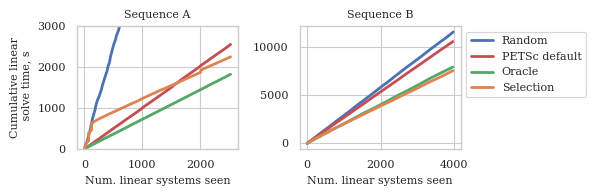

In [35]:
import numpy as np
from scipy.interpolate import interp1d


def resample_data(df_sim):
    resampled = []
    for seq_id in ALL_RUNS:
        y = np.array(df_sim.real_solve_time[df_sim.seq_id == seq_id])
        y = np.cumsum(y)

        x_old = np.arange(y.size)
        f = interp1d(x_old, y, kind="linear")
        x_new = np.linspace(0, len(x_old) - 1, 2600, endpoint=True)
        resampled.append(f(x_new))
    return x_new, resampled

def make_plot(df_sim_rand, df_sim_petsc_default, df_sim_expert, df_sim_selection):

    x, resampled = resample_data(df_sim=df_sim_rand)
    plt.plot(x, np.mean(resampled, axis=0), color="C0", linewidth=2, label='Random', alpha=1)

    x, resampled = resample_data(df_sim=df_sim_petsc_default)
    plt.plot(x, np.mean(resampled, axis=0), color="C3", linewidth=2, label='PETSc default', alpha=1)

    x, resampled = resample_data(df_sim=df_sim_expert)
    plt.plot(x, np.mean(resampled, axis=0), color="C2", linewidth=2, label='Oracle', alpha=1)

    x, resampled = resample_data(df_sim=df_sim_selection)
    plt.plot(x, np.mean(resampled, axis=0), color="C1", linewidth=2, label='Selection', alpha=1)



plt.figure(figsize=(6,2))

plt.subplot(1, 2, 1)
make_plot(
    df_sim_rand=spe_data_random,
    df_sim_petsc_default=spe_data_petsc_default,
    df_sim_expert=spe_data_expert,
    df_sim_selection=spe_data_solver_selection,
)
plt.ylim(bottom=0, top=3000)
plt.ylabel('Cumulative linear\n solve time, s')
plt.xlabel('Num. linear systems seen')
plt.title('Sequence A')

plt.subplot(1, 2, 2)
make_plot(
    df_sim_rand=thm_data_random,
    df_sim_petsc_default=thm_data_petsc_default,
    df_sim_expert=thm_data_expert,
    df_sim_selection=thm_data_solver_selection,
)

plt.xlabel('Num. linear systems seen')
plt.title('Sequence B')
plt.legend(bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('figures/common_runtime.png', dpi=600)


/tmp/ipykernel_310709/2563432955.py:69: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0, top=3000)


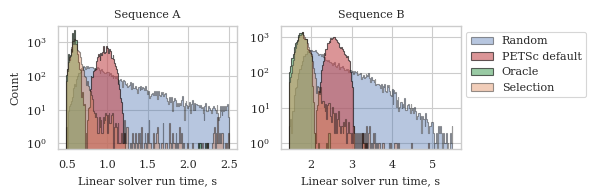

In [36]:
def make_hist(
    df_perf_rand, df_perf_petsc_default, df_perf_expert, df_perf_selection, upper_lim
):

    def extract_performance(df):
        return np.exp(-df.reward[df.reward > -200])

    data = extract_performance(df_perf_selection)
    data_rand = extract_performance(df_perf_rand)
    data_expert = extract_performance(df_perf_expert)
    data_petsc_default = extract_performance(df_perf_petsc_default)

    bins = 200
    bins = np.linspace(min(data_rand), upper_lim, bins)
    plt.hist(
        data_rand,
        bins=bins,
        density=False,
        alpha=0.4,
        edgecolor="black",
        label="Random",
        histtype="stepfilled",
        color="C0",
    )
    plt.hist(
        data_petsc_default,
        bins=bins,
        density=False,
        alpha=0.6,
        edgecolor="black",
        label="PETSc default",
        histtype="stepfilled",
        color="C3",
    )
    plt.hist(
        data_expert,
        bins=bins,
        density=False,
        alpha=0.6,
        edgecolor="black",
        label="Oracle",
        histtype="stepfilled",
        color="C2",
    )
    plt.hist(
        data,
        bins=bins,
        density=False,
        alpha=0.4,
        edgecolor="black",
        label="Selection",
        histtype="stepfilled",
        color="C1",
    )

    plt.yscale("log")


plt.figure(figsize=(6, 2))

plt.subplot(1, 2, 1)
make_hist(
    df_perf_rand=spe_perf_data_random,
    df_perf_petsc_default=spe_perf_data_petsc_default,
    df_perf_expert=spe_perf_data_expert,
    df_perf_selection=spe_perf_data_solver_selection,
    upper_lim=2.5,
)
plt.ylim(bottom=0, top=3000)
plt.xlabel("Linear solver run time, s")
plt.ylabel("Count")
plt.title("Sequence A")

plt.subplot(1, 2, 2)
make_hist(
    df_perf_rand=thm_perf_data_random,
    df_perf_petsc_default=thm_perf_data_petsc_default,
    df_perf_expert=thm_perf_data_expert,
    df_perf_selection=thm_perf_data_solver_selection,
    upper_lim=5.5,
)

plt.xlabel("Linear solver run time, s")
plt.title("Sequence B")
plt.legend(bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('figures/common_runtime_histogram.png', dpi=600)